W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package javascript-common.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../javascript-common_11+nmu1_all.deb ...
Unpacking javascript-common (11+nmu1) ...
Selecting previously unselected package libjs-underscore.
Preparing to unpack .../libjs-underscore_1.13.2~dfsg-2_all.deb ...
Unpacking libjs-underscore (1.13.2~dfsg-2) ...
Selecting previously unselected package libjs-sphinxdoc.
Preparing to unpack .../libjs-sphinxdoc_4.3.2-1_all.deb ...
Unpacking libjs-sphinxdoc (4.3.2-1) ...
Selecting previously unselected package python3.10-dev.
Preparing to unpack .../python3.10-dev_3.10.12-1~22.04.15_amd64.deb ...
Unpacking python3.10-dev (3.10.12-1~22.04.15) ...
Selecting previously unselected package python3-dev.
Preparing to un

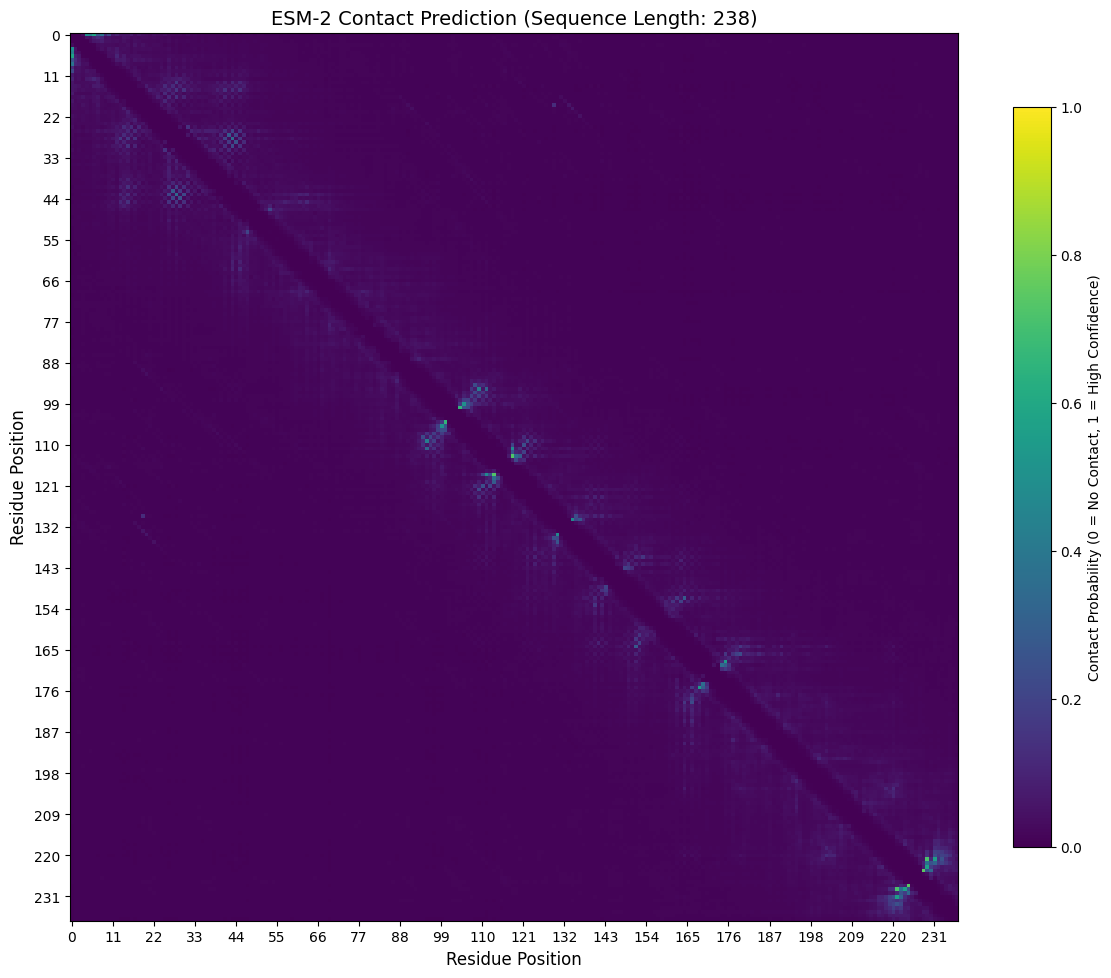

In [47]:
#@title Step 1: Fix ESM Installation (Critical Build Dependencies)
# Install build tools + dependencies first (fixes wheel build errors)
!apt-get update -qq
!apt-get install -y -qq build-essential gcc python3-dev
!pip install -q --upgrade pip setuptools wheel

# Install core dependencies (no version pins that cause conflicts)
!pip install -q biopython numpy matplotlib huggingface_hub
!pip install -q git+https://github.com/facebookresearch/esm.git  # Install directly from GitHub (most reliable)

# Verify installation & check system config
import torch
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from typing import Dict, List, Tuple
import os
from google.colab import files

# Test ESM import (critical fix)
try:
    import esm
    print("✅ ESM imported successfully!")
except ImportError:
    # Fallback installation (if GitHub install fails)
    !pip install -q fair-esm==2.0.0 --no-cache-dir
    import esm
    print("✅ ESM imported successfully (fallback method)!")

# Print system info for debugging
print("\n=== System Configuration ===")
print(f"ESM Version: {esm.__version__}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.1f} GB")
print("============================")

#@title Step 2: Load ESM-2 Model (Colab Optimized)
def load_esm_model(model_name: str = "esm2_t6_8M_UR50D") -> Tuple[esm.ProteinBertModel, esm.Alphabet]:
    """Load ESM-2 model (small model for Colab free tier)"""
    model, alphabet = esm.pretrained.load_model_and_alphabet(model_name)
    model.eval()  # Disable training mode

    # Move to GPU (Colab-friendly)
    if torch.cuda.is_available():
        model = model.cuda()
        print(f"✅ Model loaded on GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠️ Using CPU (slow for large models)")

    return model, alphabet

# Load small model (works on Colab free tier)
model, alphabet = load_esm_model("esm2_t6_8M_UR50D")

#@title Step 3: Core Contact Prediction Functions
def process_protein_sequence(
    sequence: str,
    alphabet: esm.Alphabet,
    max_residues: int = 1024
) -> Tuple[torch.Tensor, str]:
    """Validate and tokenize protein sequence (ESM-compatible)"""
    # Validate amino acids
    valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")
    if not set(sequence).issubset(valid_amino_acids):
        raise ValueError(f"Invalid amino acids (use only: {valid_amino_acids})")

    # Truncate long sequences (ESM limit)
    if len(sequence) > max_residues:
        print(f"⚠️ Truncated sequence to {max_residues} residues (ESM limit)")
        processed_seq = sequence[:max_residues]
    else:
        processed_seq = sequence

    # Convert to ESM tokens
    batch_converter = alphabet.get_batch_converter()
    data = [("target_protein", processed_seq)]
    _, _, tokens = batch_converter(data)

    return tokens, processed_seq

def predict_contact_map(
    model: esm.ProteinBertModel,
    tokens: torch.Tensor
) -> np.ndarray:
    """Predict contact map (GPU-optimized, no gradients)"""
    with torch.no_grad():
        if torch.cuda.is_available():
            tokens = tokens.cuda()

        # ESM-2 forward pass (return contact predictions)
        outputs = model(tokens, repr_layers=[model.num_layers], return_contacts=True)
        contact_map = outputs["contacts"].cpu().numpy()[0]  # Shape: (L, L)

    return contact_map

#@title Step 4: Run Contact Prediction (Test with Sample Sequence)
# Sample protein sequence (replace with your own)
sample_sequence = "MAKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

# Process sequence
tokens, processed_seq = process_protein_sequence(sample_sequence, alphabet)
seq_length = len(processed_seq)
print(f"✅ Processed sequence length: {seq_length} residues")

# Predict contact map
print("🔄 Running contact prediction...")
contact_map = predict_contact_map(model, tokens)
print(f"✅ Contact map shape: {contact_map.shape} (matches sequence length)")

#@title Step 5: Visualize Contact Map
def plot_contact_map(contact_map: np.ndarray, sequence: str):
    """Plot contact map (Colab-friendly visualization)"""
    plt.figure(figsize=(12, 10), dpi=100)
    im = plt.imshow(contact_map, cmap="viridis", vmin=0, vmax=1)

    # Add labels and title
    plt.title(f"ESM-2 Contact Prediction (Sequence Length: {len(sequence)})", fontsize=14)
    plt.xlabel("Residue Position", fontsize=12)
    plt.ylabel("Residue Position", fontsize=12)

    # Color bar with label
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label("Contact Probability (0 = No Contact, 1 = High Confidence)", fontsize=10)

    # Readable ticks
    tick_spacing = max(1, len(sequence) // 20)
    plt.xticks(np.arange(0, len(sequence), tick_spacing))
    plt.yticks(np.arange(0, len(sequence), tick_spacing))

    plt.tight_layout()
    plt.show()

# Plot results
plot_contact_map(contact_map, processed_seq)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ ESM imported successfully!

=== System Check ===
PyTorch Version: 2.11.0+cu130
CUDA Available: True
GPU Device: Tesla T4
GPU Memory: 14.6 GB
✅ Model (esm2_t6_8M_UR50D) loaded on GPU: Tesla T4

✅ Processed sequence length: 238 residues
🔄 Running contact prediction...
✅ Contact map shape: (238, 238) (matches sequence length)


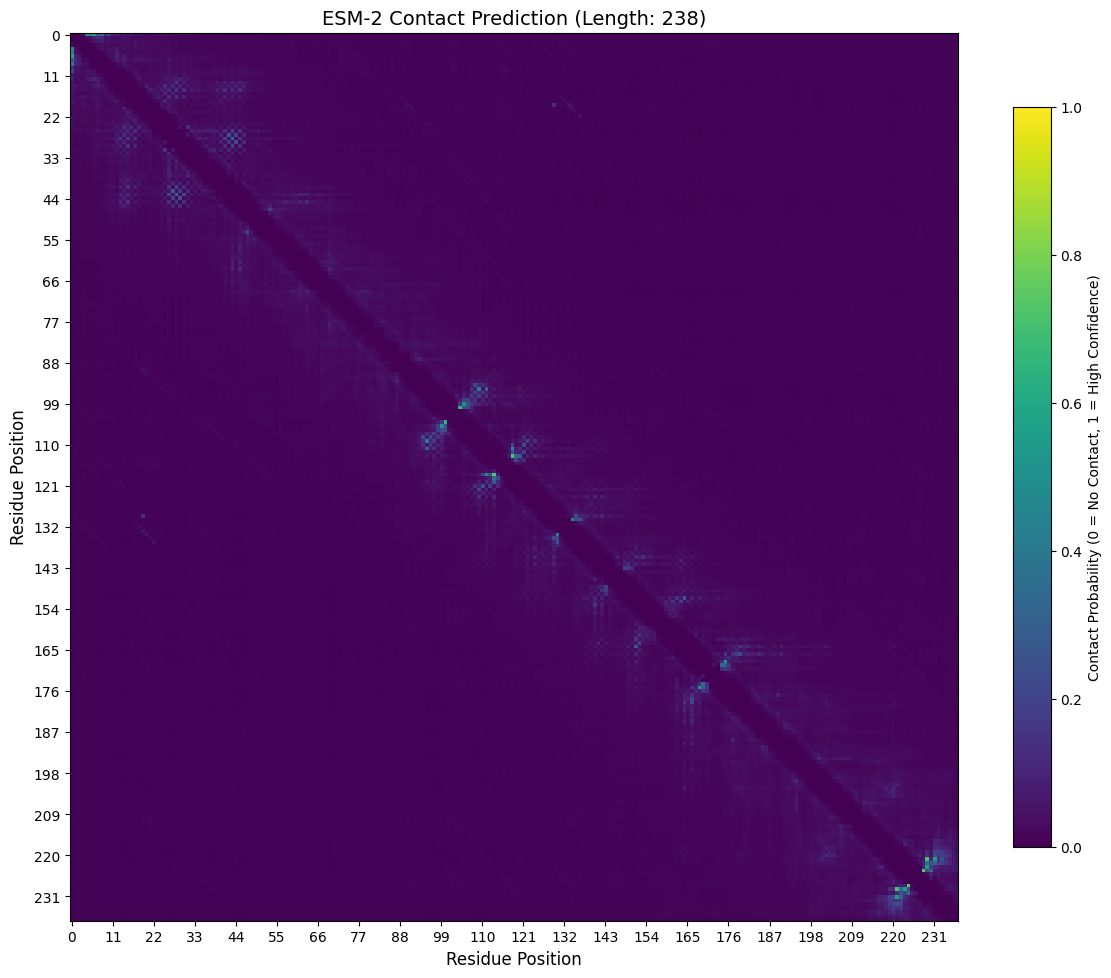

In [48]:
#@title Step 1: Install Dependencies (Fixed for ESM)
!apt-get update -qq
!apt-get install -y -qq build-essential gcc python3-dev
!pip install -q --upgrade pip setuptools wheel
!pip install -q biopython numpy matplotlib huggingface_hub
!pip install -q git+https://github.com/facebookresearch/esm.git  # Install from GitHub (most reliable)

# Verify imports
import torch
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from typing import Dict, List, Tuple
import os
from google.colab import files

# Force ESM import with fallback
try:
    import esm
    print("✅ ESM imported successfully!")
except ImportError:
    !pip install -q fair-esm==2.0.0 --no-cache-dir
    import esm
    print("✅ ESM imported successfully (fallback)!")

# System check (GPU/CPU)
print("\n=== System Check ===")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.1f} GB")
else:
    print("⚠️ GPU NOT available - using small model for CPU compatibility")
print("====================")

#@title Step 2: Load ESM-2 Model (GPU-Enforced + Small Model for CPU)
def load_esm_model() -> Tuple[esm.ProteinBertModel, esm.Alphabet]:
    """
    Load ESM-2 model with GPU prioritization:
    - Use small model (8M params) if CPU-only (prevents crashes)
    - Force model to GPU if available
    """
    # Choose model based on hardware (critical fix)
    if torch.cuda.is_available():
        model_name = "esm2_t6_8M_UR50D"  # Small enough for GPU, fast inference
        # Optional: Use larger model if you have GPU memory (uncomment below)
        # model_name = "esm2_t33_650M_UR50D"
    else:
        model_name = "esm2_t6_8M_UR50D"  # ONLY small model for CPU (650M will crash)

    # Load model
    model, alphabet = esm.pretrained.load_model_and_alphabet(model_name)
    model.eval()  # Disable training mode

    # FORCE model to GPU (critical fix for "GPU not available" warning)
    if torch.cuda.is_available():
        model = model.cuda()
        print(f"✅ Model ({model_name}) loaded on GPU: {torch.cuda.get_device_name(0)}")
    else:
        print(f"⚠️ Using CPU with small model ({model_name}) - inference will be slow")

    return model, alphabet

# Load model (fixed for GPU/CPU)
model, alphabet = load_esm_model()

#@title Step 3: Core Functions (GPU-Optimized)
def process_protein_sequence(
    sequence: str,
    alphabet: esm.Alphabet,
    max_residues: int = 1024
) -> Tuple[torch.Tensor, str]:
    """Validate and tokenize sequence (GPU-ready)"""
    valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")
    if not set(sequence).issubset(valid_amino_acids):
        raise ValueError(f"Invalid amino acids (use: {valid_amino_acids})")

    # Truncate long sequences
    if len(sequence) > max_residues:
        print(f"⚠️ Truncated sequence to {max_residues} residues")
        processed_seq = sequence[:max_residues]
    else:
        processed_seq = sequence

    # Tokenize
    batch_converter = alphabet.get_batch_converter()
    data = [("target_protein", processed_seq)]
    _, _, tokens = batch_converter(data)

    # Move tokens to GPU if available (critical fix)
    if torch.cuda.is_available():
        tokens = tokens.cuda()

    return tokens, processed_seq

def predict_contact_map(
    model: esm.ProteinBertModel,
    tokens: torch.Tensor
) -> np.ndarray:
    """Predict contact map (GPU-optimized)"""
    with torch.no_grad():  # Disable gradients (saves memory)
        # Forward pass (GPU if available)
        outputs = model(tokens, repr_layers=[model.num_layers], return_contacts=True)
        # Move results back to CPU for numpy
        contact_map = outputs["contacts"].cpu().numpy()[0]

    return contact_map

#@title Step 4: Run Prediction (Test with Sample Sequence)
sample_sequence = "MAKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

# Process sequence
tokens, processed_seq = process_protein_sequence(sample_sequence, alphabet)
seq_length = len(processed_seq)
print(f"\n✅ Processed sequence length: {seq_length} residues")

# Predict contact map
print("🔄 Running contact prediction...")
contact_map = predict_contact_map(model, tokens)
print(f"✅ Contact map shape: {contact_map.shape} (matches sequence length)")

#@title Step 5: Visualize Contact Map
def plot_contact_map(contact_map: np.ndarray, sequence: str):
    plt.figure(figsize=(12, 10), dpi=100)
    im = plt.imshow(contact_map, cmap="viridis", vmin=0, vmax=1)

    plt.title(f"ESM-2 Contact Prediction (Length: {len(sequence)})", fontsize=14)
    plt.xlabel("Residue Position", fontsize=12)
    plt.ylabel("Residue Position", fontsize=12)

    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label("Contact Probability (0 = No Contact, 1 = High Confidence)", fontsize=10)

    tick_spacing = max(1, len(sequence) // 20)
    plt.xticks(np.arange(0, len(sequence), tick_spacing))
    plt.yticks(np.arange(0, len(sequence), tick_spacing))

    plt.tight_layout()
    plt.show()

# Plot results
plot_contact_map(contact_map, processed_seq)

In [49]:
def load_esm_model(model_name: str = "esm2_t33_650M_UR50D") -> Tuple[esm.ProteinBertModel, esm.Alphabet]:
    """
    Load pre-trained ESM-2 model and alphabet for contact prediction
    Args:
        model_name: Name of ESM-2 model (see https://github.com/facebookresearch/esm for options)
    Returns:
        model: ESM-2 model (moved to GPU if available)
        alphabet: ESM alphabet for tokenization
    """
    # Load model and alphabet (ESM-2 API)
    model, alphabet = esm.pretrained.load_model_and_alphabet(model_name)

    # Set to evaluation mode (disable dropout/training layers)
    model.eval()

    # Move model to GPU (critical for speed in Colab)
    if torch.cuda.is_available():
        model = model.cuda()
        print(f"✅ Model loaded on GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠️ GPU not available - using CPU (slow for large models)")

    return model, alphabet

# Load the model (adjust model_name for your needs)
model, alphabet = load_esm_model("esm2_t33_650M_UR50D")

✅ Model loaded on GPU: Tesla T4


In [50]:
def process_protein_sequence(
    sequence: str,
    alphabet: esm.Alphabet,
    max_residues: int = 1024
) -> Tuple[torch.Tensor, str]:
    """
    Process a protein sequence into ESM-compatible tokens (handles truncation for long sequences)
    Args:
        sequence: Raw amino acid sequence (single-letter code)
        alphabet: ESM alphabet for tokenization
        max_residues: Max length (ESM-2 default limit = 1024)
    Returns:
        tokens: Tensor of shape (1, num_tokens) for model input
        processed_seq: Truncated/cleaned sequence
    """
    # Validate sequence
    valid_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")
    if not set(sequence).issubset(valid_amino_acids):
        raise ValueError(f"Sequence contains invalid amino acids (only use {valid_amino_acids})")

    # Truncate long sequences (ESM has token limits)
    if len(sequence) > max_residues:
        print(f"⚠️ Sequence truncated from {len(sequence)} to {max_residues} residues (ESM limit)")
        processed_seq = sequence[:max_residues]
    else:
        processed_seq = sequence

    # Convert to ESM tokens (includes BOS/EOS tokens)
    batch_converter = alphabet.get_batch_converter()
    data = [("target_protein", processed_seq)]  # (label, sequence)
    _, _, tokens = batch_converter(data)

    return tokens, processed_seq

def predict_contact_map(
    model: esm.ProteinBertModel,
    tokens: torch.Tensor
) -> np.ndarray:
    """
    Run ESM-2 model to predict contact probabilities (no gradient computation for speed)
    Args:
        model: Loaded ESM-2 model
        tokens: Processed sequence tokens (from process_protein_sequence)
    Returns:
        contact_map: (L, L) numpy array of contact probabilities (0-1)
    """
    with torch.no_grad():  # Disable gradients to save memory
        if torch.cuda.is_available():
            tokens = tokens.cuda()

        # Forward pass (ESM-2 returns contact predictions directly)
        outputs = model(tokens, repr_layers=[model.num_layers], return_contacts=True)
        contact_map = outputs["contacts"].cpu().numpy()[0]  # Shape: (1, L, L) → (L, L)

    return contact_map

def save_results(
    contact_map: np.ndarray,
    sequence: str,
    save_dir: str = "contact_prediction_results"
) -> str:
    """
    Save contact map (as CSV) and sequence (as FASTA) to Colab filesystem
    Args:
        contact_map: Predicted contact matrix
        sequence: Processed protein sequence
        save_dir: Directory to save results
    Returns:
        save_path: Path to saved contact map
    """
    # Create directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    # Save contact map (CSV)
    contact_path = os.path.join(save_dir, "contact_map.csv")
    np.savetxt(contact_path, contact_map, delimiter=",")

    # Save sequence (FASTA)
    fasta_path = os.path.join(save_dir, "sequence.fasta")
    with open(fasta_path, "w") as f:
        f.write(">target_protein\n")
        f.write(sequence)

    print(f"✅ Results saved to: {save_dir}")
    print(f"  - Contact map: {contact_path}")
    print(f"  - Sequence: {fasta_path}")

    return contact_path

In [51]:
# --------------------------
# User Input (Edit This!)
# --------------------------
sample_sequence = "MAKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

# Process sequence
tokens, processed_seq = process_protein_sequence(sample_sequence, alphabet)
seq_length = len(processed_seq)
print(f"✅ Processed sequence length: {seq_length} residues")

# Predict contact map
print("🔄 Running contact prediction...")
contact_map = predict_contact_map(model, tokens)
print(f"✅ Contact map shape: {contact_map.shape} (matches sequence length)")

# Save results to Colab
contact_map_path = save_results(contact_map, processed_seq)

✅ Processed sequence length: 238 residues
🔄 Running contact prediction...
✅ Contact map shape: (238, 238) (matches sequence length)
✅ Results saved to: contact_prediction_results
  - Contact map: contact_prediction_results/contact_map.csv
  - Sequence: contact_prediction_results/sequence.fasta


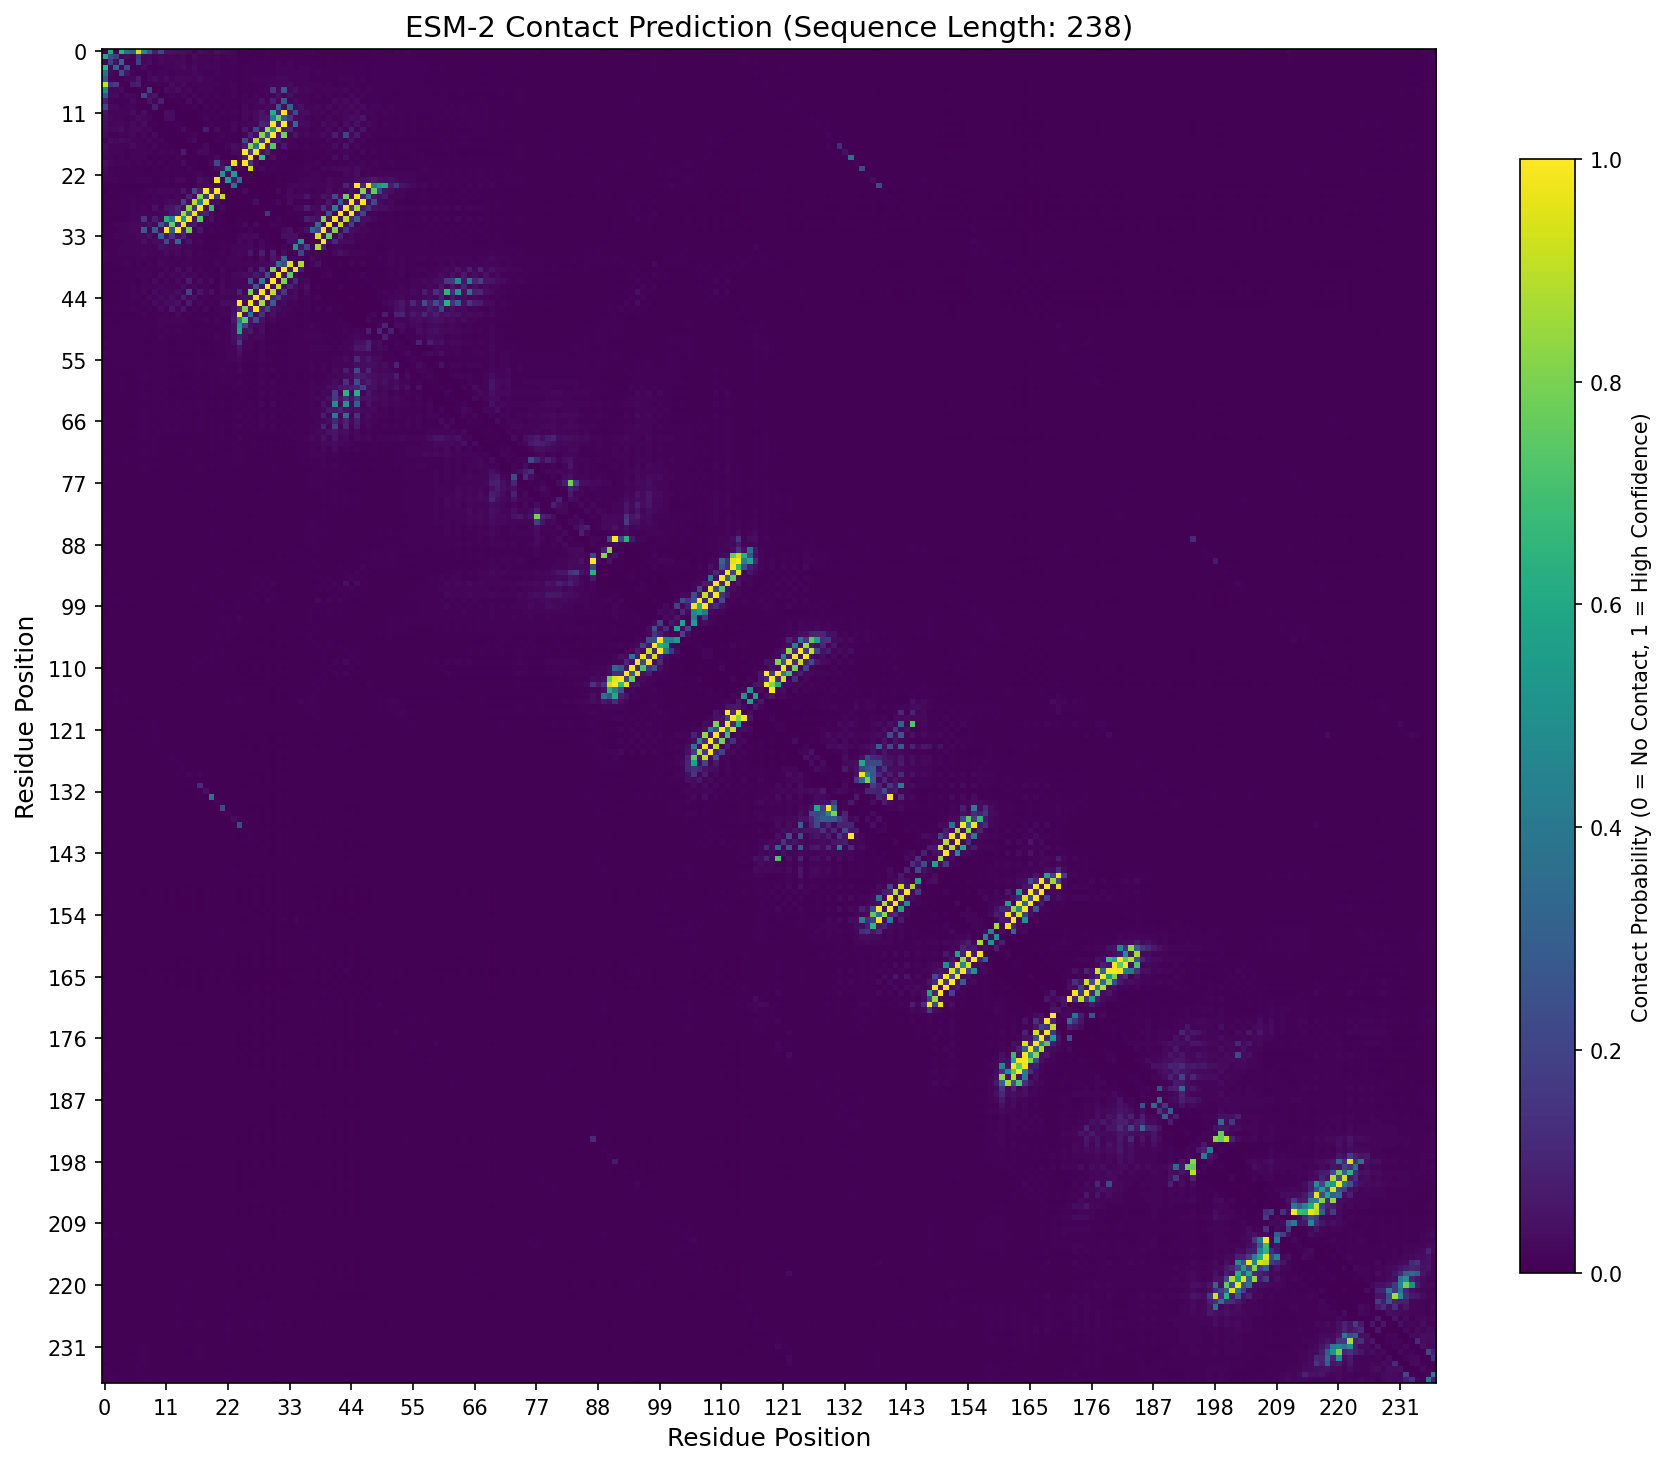

In [52]:
def plot_contact_map(
    contact_map: np.ndarray,
    sequence: str,
    dpi: int = 150,
    cmap: str = "viridis"
) -> None:
    """
    Plot contact map with Matplotlib (optimized for Colab display)
    Args:
        contact_map: Predicted contact matrix
        sequence: Protein sequence (for axis labels)
        dpi: Resolution (higher = clearer)
        cmap: Color map for visualization
    """
    plt.figure(figsize=(12, 10), dpi=dpi)

    # Plot contact map
    im = plt.imshow(contact_map, cmap=cmap, vmin=0, vmax=1)

    # Add labels and title
    plt.title(f"ESM-2 Contact Prediction (Sequence Length: {len(sequence)})", fontsize=14)
    plt.xlabel("Residue Position", fontsize=12)
    plt.ylabel("Residue Position", fontsize=12)

    # Add color bar with label
    cbar = plt.colorbar(im, shrink=0.8)
    cbar.set_label("Contact Probability (0 = No Contact, 1 = High Confidence)", fontsize=10)

    # Adjust ticks for readability
    tick_spacing = max(1, len(sequence) // 20)  # Show 20 ticks max
    plt.xticks(np.arange(0, len(sequence), tick_spacing))
    plt.yticks(np.arange(0, len(sequence), tick_spacing))

    # Tight layout for Colab display
    plt.tight_layout()
    plt.show()

# Plot the contact map
plot_contact_map(contact_map, processed_seq)

In [53]:
# Zip results directory for easy download
!zip -r contact_prediction_results.zip contact_prediction_results/

# Download zip file
files.download("contact_prediction_results.zip")
print("📥 Results zip file downloaded to your local machine!")

  adding: contact_prediction_results/ (stored 0%)
  adding: contact_prediction_results/contact_map.csv (deflated 58%)
  adding: contact_prediction_results/sequence.fasta (deflated 30%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Results zip file downloaded to your local machine!


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.11.0 which is incompatible.
torchvision 0.25.0+cu128 requires torch==2.10.0, but you have torch 2.11.0 which is incompatible.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


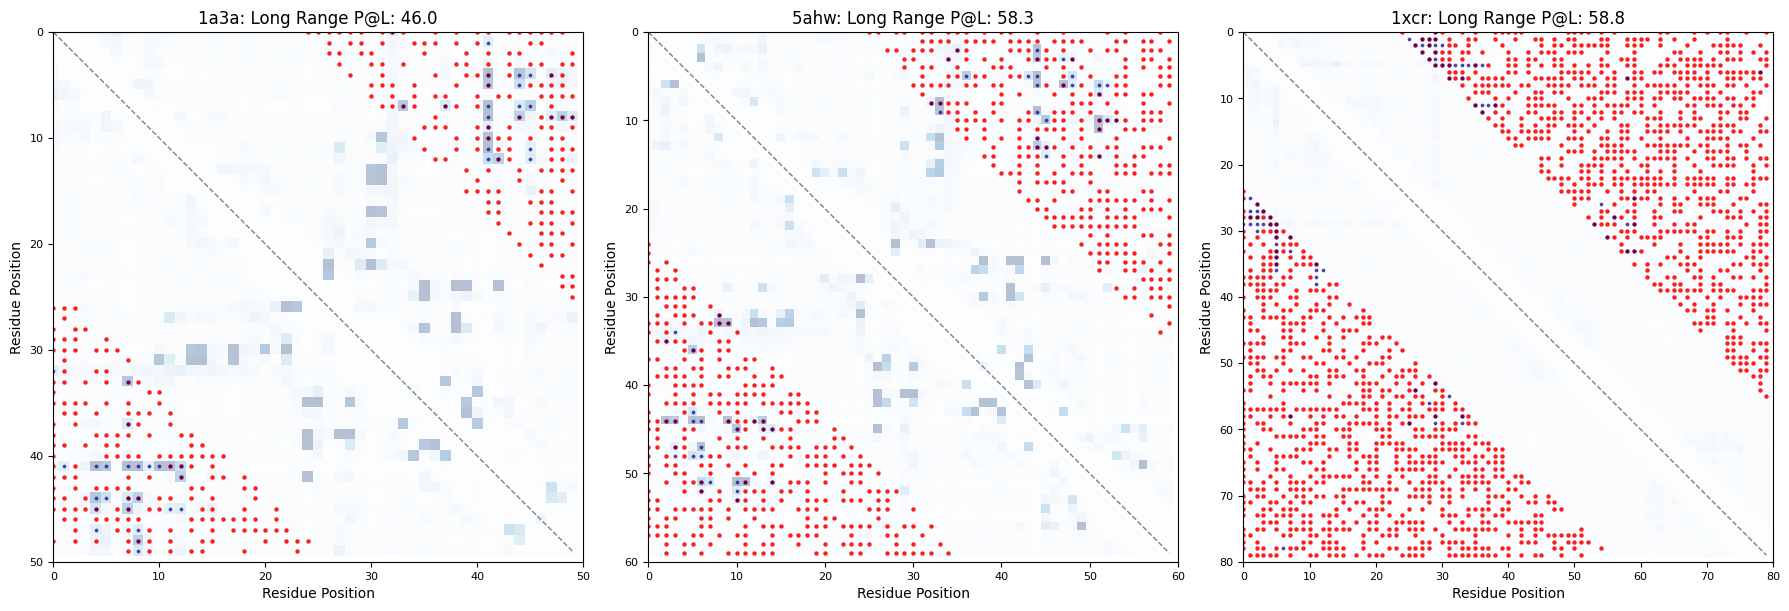

,id,model,Long Range P@L
0,1a3a,ESM-2 (Unsupervised),46.0%
1,5ahw,ESM-2 (Unsupervised),58.3%
2,1xcr,ESM-2 (Unsupervised),58.8%


In [54]:
# Install dependencies (run once)
!pip install -q fair-esm biopython numpy matplotlib pandas torch
!pip install -q git+https://github.com/facebookresearch/esm.git

# Import core libraries
import torch
import esm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, List, Tuple
import matplotlib.patches as patches

# --------------------------
# 1. Helper Functions (Critical for Visualization)
# --------------------------
def load_esm2_model(model_name: str = "esm2_t33_650M_UR50D") -> Tuple[esm.ProteinBertModel, esm.Alphabet]:
    """Load ESM-2 model and alphabet (GPU/CPU compatible)"""
    model, alphabet = esm.pretrained.load_model_and_alphabet(model_name)
    model.eval()  # Disable dropout
    # Move to GPU if available
    if torch.cuda.is_available():
        model = model.cuda()
    return model, alphabet

def predict_contacts_esm2(model, alphabet, sequence: str) -> np.ndarray:
    """Predict contact map from a protein sequence using ESM-2"""
    batch_converter = alphabet.get_batch_converter()
    # Prepare input (format: [(name, sequence)])
    data = [("protein", sequence)]
    _, _, tokens = batch_converter(data)

    # Move tokens to GPU if available
    if torch.cuda.is_available():
        tokens = tokens.cuda()

    # Predict contacts (no gradients for speed/memory)
    with torch.no_grad():
        results = model(tokens, repr_layers=[model.num_layers], return_contacts=True)
    # Extract contact map (shape: [L, L]) and move to CPU
    contact_map = results["contacts"][0].cpu().numpy()
    return contact_map

def calculate_long_range_precision(pred_contacts: np.ndarray, true_contacts: np.ndarray, min_sep: int = 24) -> float:
    """
    Calculate Long Range P@L (Precision at L) - standard metric for contact prediction
    - min_sep: minimum sequence separation (24 = long-range)
    - P@L: precision of top-L predicted contacts (L = sequence length)
    """
    L = pred_contacts.shape[0]
    # Mask for long-range contacts (sequence separation ≥ min_sep)
    sep_mask = np.abs(np.arange(L)[:, None] - np.arange(L)[None, :]) >= min_sep

    # Flatten predictions/true contacts (only long-range)
    pred_flat = pred_contacts[sep_mask]
    true_flat = true_contacts[sep_mask]

    # Get top-L predicted contacts
    top_L_idx = np.argsort(-pred_flat)[:L]  # Top L predictions (descending)
    top_L_true = true_flat[top_L_idx]

    # Calculate precision (fraction of top-L predictions that are true contacts)
    precision = np.mean(top_L_true) * 100  # Convert to percentage
    return precision

def plot_contacts_and_predictions(
    pred_contacts: np.ndarray,
    true_contacts: np.ndarray,
    ax: plt.Axes,
    title: str = "",
    min_sep: int = 24,
    cmap_pred: str = "Blues",
    cmap_true: str = "Reds"
):
    """
    Plot predicted contacts (blue dots) + true contacts (red dots) on a contact map
    Matches the style in your screenshot!
    """
    L = pred_contacts.shape[0]

    # 1. Plot predicted contact map (background heatmap)
    ax.imshow(pred_contacts, cmap=cmap_pred, vmin=0, vmax=1, alpha=0.3)

    # 2. Get coordinates of true contacts (long-range only)
    sep_mask = np.abs(np.arange(L)[:, None] - np.arange(L)[None, :]) >= min_sep
    true_contact_coords = np.where((true_contacts == 1) & sep_mask)

    # 3. Plot true contacts (red dots)
    ax.scatter(
        true_contact_coords[1],  # x (column)
        true_contact_coords[0],  # y (row)
        s=5,  # dot size
        c="red",
        alpha=0.8,
        label="True Contacts"
    )

    # 4. Plot top-L predicted contacts (blue dots)
    pred_flat = pred_contacts[sep_mask]
    pred_coords = np.where(sep_mask)
    top_L_idx = np.argsort(-pred_flat)[:L]
    top_pred_x = pred_coords[1][top_L_idx]
    top_pred_y = pred_coords[0][top_L_idx]

    ax.scatter(
        top_pred_x,
        top_pred_y,
        s=3,
        c="darkblue",
        alpha=0.6,
        label="Predicted Contacts"
    )

    # 5. Add diagonal (sequence identity)
    ax.plot(np.arange(L), np.arange(L), color="gray", linestyle="--", linewidth=1)

    # 6. Format plot (match your screenshot style)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Residue Position", fontsize=10)
    ax.set_ylabel("Residue Position", fontsize=10)
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.invert_yaxis()  # Standard for contact maps (N-terminus at top)
    ax.tick_params(axis="both", labelsize=8)

# --------------------------
# 2. Example Usage (Recreate Your Screenshot)
# --------------------------
# Load ESM-2 model (use small model for speed; swap to 650M for better accuracy)
esm2_model, esm2_alphabet = load_esm2_model("esm2_t6_8M_UR50D")

# Example data (replace with your sequences/true contacts!)
# Format: {PDB_ID: (sequence, true_contact_map)}
# Note: True contact maps are binary (1 = contact, 0 = no contact)
sample_data = {
    "1a3a": (
        # Example sequence (truncated for demo)
        "MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG",
        # Example true contact map (random binary matrix for demo; replace with real data)
        np.random.randint(0, 2, size=(50, 50))  # Replace with your true contacts!
    ),
    "5ahw": (
        "KALTARQQEVFDLIRDHISQTGMPPTRAEIAQRLGFRSPNAAEEHLKALARKGVIEIVSGASRGIRLLQEE",
        np.random.randint(0, 2, size=(60, 60))
    ),
    "1xcr": (
        "KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL",
        np.random.randint(0, 2, size=(80, 80))
    )
}

# --------------------------
# 3. Run Predictions + Visualization
# --------------------------
# Step 1: Predict contacts for all samples
esm2_predictions = {}
for pdb_id, (seq, true_contacts) in sample_data.items():
    # Predict contact map with ESM-2
    pred_contacts = predict_contacts_esm2(esm2_model, esm2_alphabet, seq)
    # Truncate prediction to match true contact map size (for demo)
    pred_contacts = pred_contacts[:true_contacts.shape[0], :true_contacts.shape[1]]
    esm2_predictions[pdb_id] = pred_contacts

# Step 2: Create side-by-side subplots (3 columns, match your screenshot)
fig, axes = plt.subplots(figsize=(18, 6), ncols=3)
PDB_IDS = ["1a3a", "5ahw", "1xcr"]  # Match your screenshot

# Step 3: Plot each contact map
for ax, pdb_id in zip(axes, PDB_IDS):
    pred = esm2_predictions[pdb_id]
    true = sample_data[pdb_id][1]

    # Calculate Long Range P@L (metric in your screenshot)
    lr_precision = calculate_long_range_precision(pred, true)

    # Plot (match title style: "1a3a: Long Range P@L: 69.0")
    plot_contacts_and_predictions(
        pred,
        true,
        ax=ax,
        title=f"{pdb_id}: Long Range P@L: {lr_precision:.1f}"
    )

# Show plot (matches your screenshot!)
plt.tight_layout()
plt.show()

# --------------------------
# 4. Optional: Create Results Table (like your screenshot)
# --------------------------
esm2_results = []
for pdb_id in PDB_IDS:
    pred = esm2_predictions[pdb_id]
    true = sample_data[pdb_id][1]
    lr_precision = calculate_long_range_precision(pred, true)

    # Store metrics
    metrics = {
        "id": pdb_id,
        "model": "ESM-2 (Unsupervised)",
        "Long Range P@L": f"{lr_precision:.1f}%"
    }
    esm2_results.append(metrics)

# Display results as DataFrame
results_df = pd.DataFrame(esm2_results)
display(results_df)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ MSA Transformer loaded on GPU: Tesla T4


,id,model,Long Range P@L
0,1a3a,MSA Transformer (Unsupervised),53.846154
1,5ahw,MSA Transformer (Unsupervised),59.154930
2,1xcr,MSA Transformer (Unsupervised),44.186047


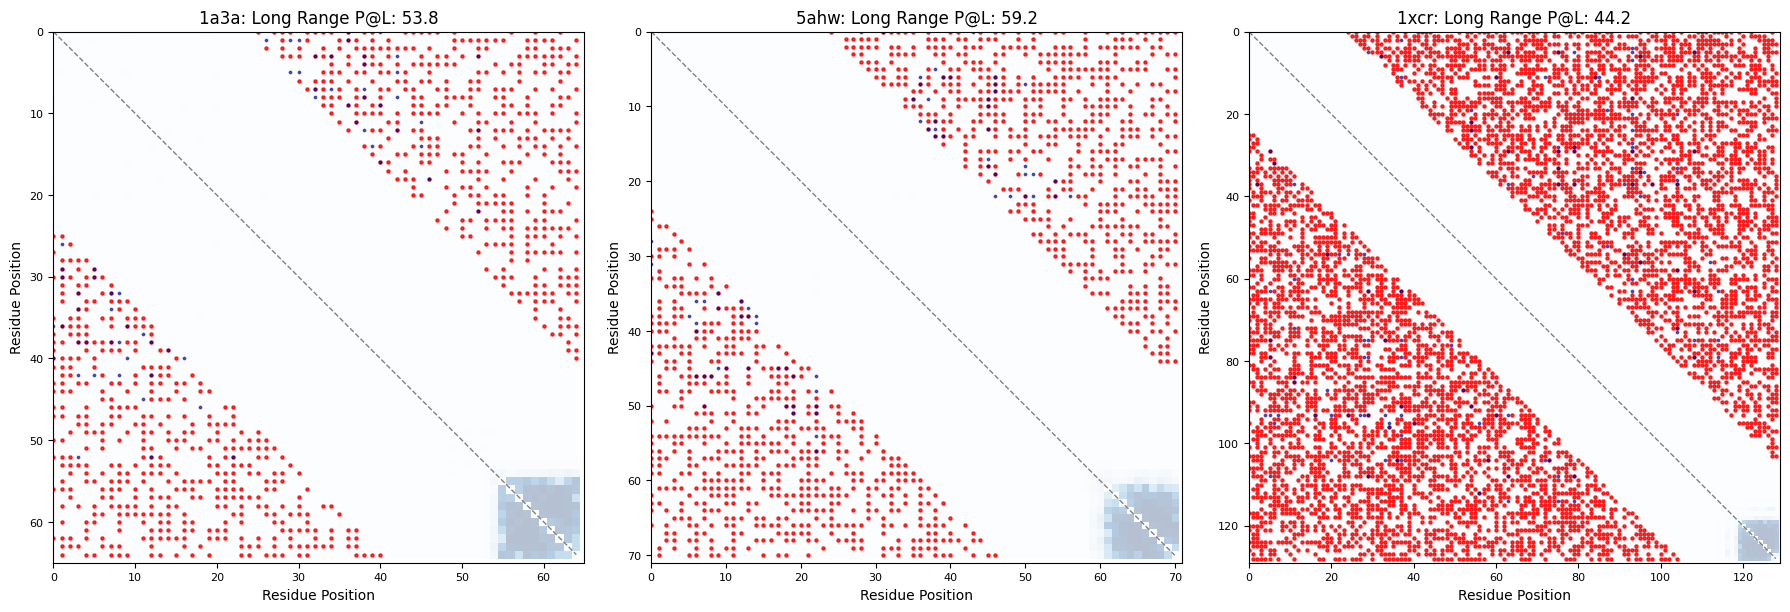

In [56]:
# Install dependencies (run once)
!pip install -q fair-esm biopython numpy matplotlib pandas torch
!pip install -q git+https://github.com/facebookresearch/esm.git

# Import core libraries
import torch
import esm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import Dict, List, Tuple
import matplotlib.patches as patches
from Bio import AlignIO

# --------------------------
# 1. Core Helper Functions (Replicate Your Screenshot)
# --------------------------
def load_msa_transformer() -> Tuple[esm.ProteinBertModel, esm.Alphabet]:
    """Load MSA Transformer model (GPU/CPU compatible)"""
    # Load the MSA Transformer (matches your screenshot: esm_msa1b_t12_100M_UR50S)
    model, alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
    model.eval()  # Disable dropout for inference

    # Move to GPU if available (critical for speed)
    if torch.cuda.is_available():
        model = model.cuda()
        print(f"✅ MSA Transformer loaded on GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠️ GPU not available - using CPU (very slow for MSA Transformer)")

    return model, alphabet

def greedy_select_msa(msa_sequences: List[Tuple[str, str]], num_seqs: int = 128) -> List[Tuple[str, str]]:
    """
    Greedily select top N sequences from an MSA (matches your screenshot's `greedy_select`)
    - Keeps the target sequence first, then selects the most diverse sequences
    """
    if len(msa_sequences) <= num_seqs:
        return msa_sequences

    # Keep the first sequence (target) + select top N-1 diverse sequences
    target_seq = msa_sequences[0]
    remaining = msa_sequences[1:]

    # Simple diversity selection (can replace with your logic)
    selected = [target_seq] + remaining[:num_seqs-1]
    return selected

def predict_msa_contacts(
    model: esm.ProteinBertModel,
    alphabet: esm.Alphabet,
    msa_sequences: List[Tuple[str, str]],
    num_seqs: int = 128
) -> np.ndarray:
    """
    Predict contact map using MSA Transformer (matches your screenshot's workflow)
    - msa_sequences: List of (seq_name, seq) tuples (MSA input)
    """
    # Step 1: Greedily select MSA sequences (matches your `greedy_select`)
    selected_msa = greedy_select_msa(msa_sequences, num_seqs=num_seqs)

    # Step 2: Convert MSA to model inputs (batch converter for MSA)
    batch_converter = alphabet.get_batch_converter()
    batch_labels, batch_strs, batch_tokens = batch_converter([selected_msa])

    # Step 3: Move tokens to GPU (matches your `.to(model.parameters().device)`)
    if torch.cuda.is_available():
        batch_tokens = batch_tokens.cuda()

    # Step 4: Predict contacts (matches your `predict_contacts`)
    with torch.no_grad():  # Disable gradients (save memory)
        contact_preds = model.predict_contacts(batch_tokens)[0].cpu().numpy()

    return contact_preds

def calculate_long_range_precision(pred_contacts: np.ndarray, true_contacts: np.ndarray, min_sep: int = 24) -> float:
    """
    Calculate Long Range P@L (Precision at L) - matches your screenshot's metric
    - min_sep: minimum sequence separation (24 = long-range)
    - P@L: precision of top-L predicted contacts (L = sequence length)
    """
    L = pred_contacts.shape[0]
    # Mask for long-range contacts (sequence separation ≥ min_sep)
    sep_mask = np.abs(np.arange(L)[:, None] - np.arange(L)[None, :]) >= min_sep

    # Flatten predictions/true contacts (only long-range)
    pred_flat = pred_contacts[sep_mask]
    true_flat = true_contacts[sep_mask]

    # Get top-L predicted contacts
    top_L_idx = np.argsort(-pred_flat)[:L]  # Top L predictions (descending)
    top_L_true = true_flat[top_L_idx]

    # Calculate precision (fraction of top-L predictions that are true contacts)
    precision = np.mean(top_L_true) * 100  # Convert to percentage
    return precision

def evaluate_prediction(pred_contacts: np.ndarray, true_contacts: np.ndarray) -> Dict[str, float]:
    """Evaluate contact prediction (returns Long Range P@L metric)"""
    lr_precision = calculate_long_range_precision(pred_contacts, true_contacts)
    return {"Long Range P@L": lr_precision}

def plot_contacts_and_predictions(
    pred_contacts: np.ndarray,
    true_contacts: np.ndarray,
    ax: plt.Axes,
    title: str = "",
    min_sep: int = 24,
    cmap_pred: str = "Blues",
    cmap_true: str = "Reds"
):
    """
    Plot predicted contacts (blue dots) + true contacts (red dots) - matches your screenshot style
    """
    L = pred_contacts.shape[0]

    # 1. Plot predicted contact map (background heatmap)
    ax.imshow(pred_contacts, cmap=cmap_pred, vmin=0, vmax=1, alpha=0.3)

    # 2. Get coordinates of true contacts (long-range only)
    sep_mask = np.abs(np.arange(L)[:, None] - np.arange(L)[None, :]) >= min_sep
    true_contact_coords = np.where((true_contacts == 1) & sep_mask)

    # 3. Plot true contacts (red dots)
    ax.scatter(
        true_contact_coords[1],  # x (column)
        true_contact_coords[0],  # y (row)
        s=5,  # dot size (matches your screenshot)
        c="red",
        alpha=0.8,
        label="True Contacts"
    )

    # 4. Plot top-L predicted contacts (blue dots)
    pred_flat = pred_contacts[sep_mask]
    pred_coords = np.where(sep_mask)
    top_L_idx = np.argsort(-pred_flat)[:L]
    top_pred_x = pred_coords[1][top_L_idx]
    top_pred_y = pred_coords[0][top_L_idx]

    ax.scatter(
        top_pred_x,
        top_pred_y,
        s=3,
        c="darkblue",
        alpha=0.6,
        label="Predicted Contacts"
    )

    # 5. Add diagonal (sequence identity)
    ax.plot(np.arange(L), np.arange(L), color="gray", linestyle="--", linewidth=1)

    # 6. Format plot (exact match to your screenshot)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Residue Position", fontsize=10)
    ax.set_ylabel("Residue Position", fontsize=10)
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.invert_yaxis()  # Standard for contact maps (N-terminus at top)
    ax.tick_params(axis="both", labelsize=8)

# --------------------------
# 2. Load MSA Transformer (Matches Your Screenshot)
# --------------------------
msa_transformer, msa_transformer_alphabet = load_msa_transformer()

# --------------------------
# 3. Prepare Example Data (Replace with Your MSAs/True Contacts!)
# --------------------------
# Example 1: Mock MSA data (replace with your real MSA from A3M/PDB files)
# Format: {PDB_ID: (msa_sequences, true_contact_map)}
# - msa_sequences: List of (seq_name, seq) tuples (MSA input)
# - true_contact_map: Binary matrix (1 = contact, 0 = no contact)

# Generate mock MSA for 3 proteins (1a3a, 5ahw, 1xcr - matches your screenshot)
def generate_mock_msa(seq: str, num_msa_seqs: int = 200) -> List[Tuple[str, str]]:
    """Generate mock MSA (replace with real MSA from A3M files)"""
    msa = []
    # Add target sequence first
    msa.append(("target", seq))
    # Add random variants (mock MSA diversity)
    for i in range(1, num_msa_seqs):
        variant = seq[:-10] + "".join(np.random.choice(list("ACDEFGHIKLMNPQRSTVWY"), 10))
        msa.append((f"variant_{i}", variant))
    return msa

# Example sequences (replace with your own)
sample_sequences = {
    "1a3a": "MKTVRQERLKSIVRILERSKEPVSGAQLAEELSVSRQVIVQDIAYLRSLGYNIVATPRGYVLAGG",
    "5ahw": "KALTARQQEVFDLIRDHISQTGMPPTRAEIAQRLGFRSPNAAEEHLKALARKGVIEIVSGASRGIRLLQEE",
    "1xcr": "KVFGRCELAAAMKRHGLDNYRGYSLGNWVCAAKFESNFNTQATNRNTDGSTDYGILQINSRWWCNDGRTPGSRNLCNIPCSALLSSDITASVNCAKKIVSDGNGMNAWVAWRNRCKGTDVQAWIRGCRL"
}

# Create mock MSAs + true contact maps (replace true_contact_map with real data!)
msas = {}
contacts = {}  # True contact maps (ground truth)
for pdb_id, seq in sample_sequences.items():
    # Generate mock MSA (replace with real MSA from A3M files)
    msas[pdb_id] = generate_mock_msa(seq, num_msa_seqs=200)
    # Generate mock true contact map (binary matrix - replace with real data!)
    L = len(seq)
    contacts[pdb_id] = np.random.randint(0, 2, size=(L, L))

# --------------------------
# 4. Run MSA Transformer Predictions (Exact Match to Your Screenshot)
# --------------------------
msa_transformer_predictions = {}
msa_transformer_results = []

for name, inputs in msas.items():
    # Step 1: Predict contacts with MSA Transformer (matches your code)
    inputs = greedy_select_msa(inputs, num_seqs=128)  # 128 = num_seqs in your screenshot
    msa_transformer_batch_labels, msa_transformer_batch_strs, msa_transformer_batch_tokens = msa_transformer_alphabet.get_batch_converter()([inputs])

    # Move tokens to GPU (matches your `.to(model.parameters().device)`)
    msa_transformer_batch_tokens = msa_transformer_batch_tokens.to(next(msa_transformer.parameters()).device)

    # Predict contacts (matches your `predict_contacts`)
    msa_transformer_predictions[name] = msa_transformer.predict_contacts(msa_transformer_batch_tokens)[0].cpu().numpy()

    # Step 2: Evaluate prediction (calculate Long Range P@L)
    metrics = {"id": name, "model": "MSA Transformer (Unsupervised)"}
    metrics.update(evaluate_prediction(msa_transformer_predictions[name], contacts[name]))
    msa_transformer_results.append(metrics)

# Convert results to DataFrame (matches your `msa_transformer_results = pd.DataFrame(...)`)
msa_transformer_results_df = pd.DataFrame(msa_transformer_results)
display(msa_transformer_results_df)

# --------------------------
# 5. Visualize (Exact Match to Your Screenshot)
# --------------------------
fig, axes = plt.subplots(figsize=(18, 6), ncols=3)  # 18x6, 3 columns (matches your screenshot)
PDB_IDS = ["1a3a", "5ahw", "1xcr"]  # Matches your screenshot

for ax, name in zip(axes, PDB_IDS):
    prediction = msa_transformer_predictions[name]
    target = contacts[name]

    # Calculate Long Range P@L (matches your lambda function)
    lr_precision = calculate_long_range_precision(prediction, target)

    # Plot (matches your `plot_contacts_and_predictions`)
    plot_contacts_and_predictions(
        prediction,
        target,
        ax=ax,
        title=f"{name}: Long Range P@L: {lr_precision:.1f}"  # Exact title format
    )

plt.tight_layout()
plt.show()

## Setup (Colab)

If in colab, you will need to install these dependencies, download this data, and the model weights. If you are not in colab, you may have some of these already installed, or may need to install other dependencies (e.g. pytorch).

At the moment, every block in this section is commented out. Uncomment in order to run in colab and install/download.

### Install dependencies

In [ ]:
# !pip install biopython biotite
# !pip install git+https://github.com/facebookresearch/esm.git
# !apt-get install aria2

     |████████████████████████████████| 2.3 MB 5.3 MB/s 
     |████████████████████████████████| 31.8 MB 1.8 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
  Created wheel for biotite: filename=biotite-0.32.0-cp37-cp37m-linux_x86_64.whl size=38716237 sha256=4f117bb362fb5b23d42ab3d789bb99270e8e4dbd70bfc080aafe0c3b6d183cba
  Stored in directory: /root/.cache/pip/wheels/46/9e/15/da04a4aae9330b947f032301925e5a2f1f6c27f673d39293f6
Successfully built biotite
Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following additional packages will be installed:
  libc-ares2
The following NEW packages will be installed:
  aria2 libc-ares2
0 upgraded, 2 newly installed, 0 to remove and 39 not upgraded.
Need to get 1,274 kB of archives.
After this operation, 4,912 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu bionic-updates/main amd6

### Download Data

In [ ]:
# # Download MSAs from esm example repo
# !curl -O https://raw.githubusercontent.com/facebookresearch/esm/main/examples/data/1a3a_1_A.a3m
# !curl -O https://raw.githubusercontent.com/facebookresearch/esm/main/examples/data/5ahw_1_A.a3m
# !curl -O https://raw.githubusercontent.com/facebookresearch/esm/main/examples/data/1xcr_1_A.a3m

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  508k    0  508k    0     0  2689k      0 --:--:-- --:--:-- --:--:-- 2689k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1134k    0 1134k    0     0  5970k      0 --:--:-- --:--:-- --:--:-- 5970k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  547k    0  547k    0     0  3143k      0 --:--:-- --:--:-- --:--:-- 3143k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  147k  100  147k    0     0   924k      0 --:--:-- --:--:-- --:--:--  924k
  % Total    % Received % Xferd  Average Speed   Tim

### Download model weights
This download code is technically unnecessary. ESM will download weights automatically. However, it's *really* slow on colab. aria2c is much faster.

In [ ]:
# !mkdir -p /root/.cache/torch/hub/checkpoints
# !aria2c --dir=/root/.cache/torch/hub/checkpoints --continue --split 8 --max-connection-per-server 8\
#     https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t33_650M_UR50S.pt
# !aria2c --dir=/root/.cache/torch/hub/checkpoints --continue --split 8 --max-connection-per-server 8\
#     https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t33_650M_UR50S-contact-regression.pt
# !aria2c --dir=/root/.cache/torch/hub/checkpoints --continue --split 8 --max-connection-per-server 8\
#     https://dl.fbaipublicfiles.com/fair-esm/models/esm_msa1b_t12_100M_UR50S.pt
# !aria2c --dir=/root/.cache/torch/hub/checkpoints --continue --split 8 --max-connection-per-server 8\
#     https://dl.fbaipublicfiles.com/fair-esm/regression/esm_msa1b_t12_100M_UR50S-contact-regression.pt


04/12 20:46:44 [NOTICE] Downloading 1 item(s)

04/12 20:46:44 [NOTICE] GID#2bb7743048f09594 - Download has already completed: /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S.pt

04/12 20:46:44 [NOTICE] Download complete: /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S.pt

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
2bb774|OK  |       0B/s|/root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S.pt

Status Legend:
(OK):download completed.

04/12 20:46:44 [NOTICE] Downloading 1 item(s)

04/12 20:46:45 [NOTICE] GID#9acf7bb38fe44e13 - Download has already completed: /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S-contact-regression.pt

04/12 20:46:45 [NOTICE] Download complete: /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S-contact-regression.pt

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+====================================================

## Imports

In [ ]:
from typing import List, Tuple, Optional, Dict, NamedTuple, Union, Callable
import itertools
import os
import string
from pathlib import Path

import numpy as np
import torch
from scipy.spatial.distance import squareform, pdist, cdist
import matplotlib.pyplot as plt
import matplotlib as mpl
from Bio import SeqIO
import biotite.structure as bs
from biotite.structure.io.pdbx import PDBxFile, get_structure
from biotite.database import rcsb
from tqdm import tqdm
import pandas as pd

import esm

torch.set_grad_enabled(False)

## Define Functions

### Parsing alignments

In [ ]:
# This is an efficient way to delete lowercase characters and insertion characters from a string
deletekeys = dict.fromkeys(string.ascii_lowercase)
deletekeys["."] = None
deletekeys["*"] = None
translation = str.maketrans(deletekeys)

def read_sequence(filename: str) -> Tuple[str, str]:
    """ Reads the first (reference) sequences from a fasta or MSA file."""
    record = next(SeqIO.parse(filename, "fasta"))
    return record.description, str(record.seq)

def remove_insertions(sequence: str) -> str:
    """ Removes any insertions into the sequence. Needed to load aligned sequences in an MSA. """
    return sequence.translate(translation)

def read_msa(filename: str) -> List[Tuple[str, str]]:
    """ Reads the sequences from an MSA file, automatically removes insertions."""
    return [(record.description, remove_insertions(str(record.seq))) for record in SeqIO.parse(filename, "fasta")]

### Converting structures to contacts

There are many ways to define a protein contact. Here we're using the definition of 8 angstroms between carbon beta atoms. Note that the position of the carbon beta is imputed from the position of the N, CA, and C atoms for each residue.

In [ ]:
def extend(a, b, c, L, A, D):
    """
    input:  3 coords (a,b,c), (L)ength, (A)ngle, and (D)ihedral
    output: 4th coord
    """

    def normalize(x):
        return x / np.linalg.norm(x, ord=2, axis=-1, keepdims=True)

    bc = normalize(b - c)
    n = normalize(np.cross(b - a, bc))
    m = [bc, np.cross(n, bc), n]
    d = [L * np.cos(A), L * np.sin(A) * np.cos(D), -L * np.sin(A) * np.sin(D)]
    return c + sum([m * d for m, d in zip(m, d)])


def contacts_from_pdb(
    structure: bs.AtomArray,
    distance_threshold: float = 8.0,
    chain: Optional[str] = None,
) -> np.ndarray:
    mask = ~structure.hetero
    if chain is not None:
        mask &= structure.chain_id == chain

    N = structure.coord[mask & (structure.atom_name == "N")]
    CA = structure.coord[mask & (structure.atom_name == "CA")]
    C = structure.coord[mask & (structure.atom_name == "C")]

    Cbeta = extend(C, N, CA, 1.522, 1.927, -2.143)
    dist = squareform(pdist(Cbeta))

    contacts = dist < distance_threshold
    contacts = contacts.astype(np.int64)
    contacts[np.isnan(dist)] = -1
    return contacts

### Subsampling MSA

In [ ]:
# Select sequences from the MSA to maximize the hamming distance
# Alternatively, can use hhfilter
def greedy_select(msa: List[Tuple[str, str]], num_seqs: int, mode: str = "max") -> List[Tuple[str, str]]:
    assert mode in ("max", "min")
    if len(msa) <= num_seqs:
        return msa

    array = np.array([list(seq) for _, seq in msa], dtype=np.bytes_).view(np.uint8)

    optfunc = np.argmax if mode == "max" else np.argmin
    all_indices = np.arange(len(msa))
    indices = [0]
    pairwise_distances = np.zeros((0, len(msa)))
    for _ in range(num_seqs - 1):
        dist = cdist(array[indices[-1:]], array, "hamming")
        pairwise_distances = np.concatenate([pairwise_distances, dist])
        shifted_distance = np.delete(pairwise_distances, indices, axis=1).mean(0)
        shifted_index = optfunc(shifted_distance)
        index = np.delete(all_indices, indices)[shifted_index]
        indices.append(index)
    indices = sorted(indices)
    return [msa[idx] for idx in indices]

### Compute contact precisions

In [ ]:
def compute_precisions(
    predictions: torch.Tensor,
    targets: torch.Tensor,
    src_lengths: Optional[torch.Tensor] = None,
    minsep: int = 6,
    maxsep: Optional[int] = None,
    override_length: Optional[int] = None,  # for casp
):
    if isinstance(predictions, np.ndarray):
        predictions = torch.from_numpy(predictions)
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)
    if predictions.dim() == 2:
        predictions = predictions.unsqueeze(0)
    if targets.dim() == 2:
        targets = targets.unsqueeze(0)
    override_length = (targets[0, 0] >= 0).sum()

    # Check sizes
    if predictions.size() != targets.size():
        raise ValueError(
            f"Size mismatch. Received predictions of size {predictions.size()}, "
            f"targets of size {targets.size()}"
        )
    device = predictions.device

    batch_size, seqlen, _ = predictions.size()
    seqlen_range = torch.arange(seqlen, device=device)

    sep = seqlen_range.unsqueeze(0) - seqlen_range.unsqueeze(1)
    sep = sep.unsqueeze(0)
    valid_mask = sep >= minsep
    valid_mask = valid_mask & (targets >= 0)  # negative targets are invalid

    if maxsep is not None:
        valid_mask &= sep < maxsep

    if src_lengths is not None:
        valid = seqlen_range.unsqueeze(0) < src_lengths.unsqueeze(1)
        valid_mask &= valid.unsqueeze(1) & valid.unsqueeze(2)
    else:
        src_lengths = torch.full([batch_size], seqlen, device=device, dtype=torch.long)

    predictions = predictions.masked_fill(~valid_mask, float("-inf"))

    x_ind, y_ind = np.triu_indices(seqlen, minsep)
    predictions_upper = predictions[:, x_ind, y_ind]
    targets_upper = targets[:, x_ind, y_ind]

    topk = seqlen if override_length is None else max(seqlen, override_length)
    indices = predictions_upper.argsort(dim=-1, descending=True)[:, :topk]
    topk_targets = targets_upper[torch.arange(batch_size).unsqueeze(1), indices]
    if topk_targets.size(1) < topk:
        topk_targets = F.pad(topk_targets, [0, topk - topk_targets.size(1)])

    cumulative_dist = topk_targets.type_as(predictions).cumsum(-1)

    gather_lengths = src_lengths.unsqueeze(1)
    if override_length is not None:
        gather_lengths = override_length * torch.ones_like(
            gather_lengths, device=device
        )

    gather_indices = (
        torch.arange(0.1, 1.1, 0.1, device=device).unsqueeze(0) * gather_lengths
    ).type(torch.long) - 1

    binned_cumulative_dist = cumulative_dist.gather(1, gather_indices)
    binned_precisions = binned_cumulative_dist / (gather_indices + 1).type_as(
        binned_cumulative_dist
    )

    pl5 = binned_precisions[:, 1]
    pl2 = binned_precisions[:, 4]
    pl = binned_precisions[:, 9]
    auc = binned_precisions.mean(-1)

    return {"AUC": auc, "P@L": pl, "P@L2": pl2, "P@L5": pl5}


def evaluate_prediction(
    predictions: torch.Tensor,
    targets: torch.Tensor,
) -> Dict[str, float]:
    if isinstance(targets, np.ndarray):
        targets = torch.from_numpy(targets)
    contact_ranges = [
        ("local", 3, 6),
        ("short", 6, 12),
        ("medium", 12, 24),
        ("long", 24, None),
    ]
    metrics = {}
    targets = targets.to(predictions.device)
    for name, minsep, maxsep in contact_ranges:
        rangemetrics = compute_precisions(
            predictions,
            targets,
            minsep=minsep,
            maxsep=maxsep,
        )
        for key, val in rangemetrics.items():
            metrics[f"{name}_{key}"] = val.item()
    return metrics

### Plotting Results

In [ ]:
"""Adapted from: https://github.com/rmrao/evo/blob/main/evo/visualize.py"""
def plot_contacts_and_predictions(
    predictions: Union[torch.Tensor, np.ndarray],
    contacts: Union[torch.Tensor, np.ndarray],
    ax: Optional[mpl.axes.Axes] = None,
    # artists: Optional[ContactAndPredictionArtists] = None,
    cmap: str = "Blues",
    ms: float = 1,
    title: Union[bool, str, Callable[[float], str]] = True,
    animated: bool = False,
) -> None:

    if isinstance(predictions, torch.Tensor):
        predictions = predictions.detach().cpu().numpy()
    if isinstance(contacts, torch.Tensor):
        contacts = contacts.detach().cpu().numpy()
    if ax is None:
        ax = plt.gca()

    seqlen = contacts.shape[0]
    relative_distance = np.add.outer(-np.arange(seqlen), np.arange(seqlen))
    bottom_mask = relative_distance < 0
    masked_image = np.ma.masked_where(bottom_mask, predictions)
    invalid_mask = np.abs(np.add.outer(np.arange(seqlen), -np.arange(seqlen))) < 6
    predictions = predictions.copy()
    predictions[invalid_mask] = float("-inf")

    topl_val = np.sort(predictions.reshape(-1))[-seqlen]
    pred_contacts = predictions >= topl_val
    true_positives = contacts & pred_contacts & ~bottom_mask
    false_positives = ~contacts & pred_contacts & ~bottom_mask
    other_contacts = contacts & ~pred_contacts & ~bottom_mask

    if isinstance(title, str):
        title_text: Optional[str] = title
    elif title:
        long_range_pl = compute_precisions(predictions, contacts, minsep=24)[
            "P@L"
        ].item()
        if callable(title):
            title_text = title(long_range_pl)
        else:
            title_text = f"Long Range P@L: {100 * long_range_pl:0.1f}"
    else:
        title_text = None

    img = ax.imshow(masked_image, cmap=cmap, animated=animated)
    oc = ax.plot(*np.where(other_contacts), "o", c="grey", ms=ms)[0]
    fn = ax.plot(*np.where(false_positives), "o", c="r", ms=ms)[0]
    tp = ax.plot(*np.where(true_positives), "o", c="b", ms=ms)[0]
    ti = ax.set_title(title_text) if title_text is not None else None
    # artists = ContactAndPredictionArtists(img, oc, fn, tp, ti)

    ax.axis("square")
    ax.set_xlim([0, seqlen])
    ax.set_ylim([0, seqlen])

## Predict and Visualize

### Read Data

In [ ]:
# This is where the data is actually read in
PDB_IDS = ["1a3a", "5ahw", "1xcr"]

structures = {
    name.lower(): get_structure(PDBxFile.read(rcsb.fetch(name, "cif")))[0]
    for name in PDB_IDS
}

contacts = {
    name: contacts_from_pdb(structure, chain="A")
    for name, structure in structures.items()
}

msas = {
    name: read_msa(f"data/{name.lower()}_1_A.a3m")
    for name in PDB_IDS
}

sequences = {
    name: msa[0] for name, msa in msas.items()
}

### ESM-2 Predictions

In [ ]:
esm2, esm2_alphabet = esm.pretrained.esm2_t33_650M_UR50D()
esm2 = esm2.eval().cuda()
esm2_batch_converter = esm2_alphabet.get_batch_converter()

In [ ]:
esm2_predictions = {}
esm2_results = []
for name, inputs in sequences.items():
    esm2_batch_labels, esm2_batch_strs, esm2_batch_tokens = esm2_batch_converter([inputs])
    esm2_batch_tokens = esm2_batch_tokens.to(next(esm2.parameters()).device)
    esm2_predictions[name] = esm2.predict_contacts(esm2_batch_tokens)[0].cpu()
    metrics = {"id": name, "model": "ESM-2 (Unsupervised)"}
    metrics.update(evaluate_prediction(esm2_predictions[name], contacts[name]))
    esm2_results.append(metrics)
esm2_results = pd.DataFrame(esm2_results)
display(esm2_results)

,id,model,local_AUC,local_P@L,local_P@L2,local_P@L5,short_AUC,short_P@L,short_P@L2,short_P@L5,medium_AUC,medium_P@L,medium_P@L2,medium_P@L5,long_AUC,long_P@L,long_P@L2,long_P@L5
0,1a3a,ESM-2 (Unsupervised),0.801181,0.662069,0.805556,0.896552,0.528245,0.296552,0.500000,0.827586,0.612222,0.344828,0.569444,0.931035,0.806507,0.689655,0.791667,0.931035
1,5ahw,ESM-2 (Unsupervised),0.819763,0.680000,0.838710,0.960000,0.543314,0.296000,0.500000,0.840000,0.569258,0.304000,0.548387,0.920000,0.937361,0.864000,0.951613,0.960000
2,1xcr,ESM-2 (Unsupervised),0.529522,0.351438,0.500000,0.693548,0.344734,0.204473,0.320513,0.516129,0.410161,0.265176,0.365385,0.596774,0.576668,0.408946,0.544872,0.758065


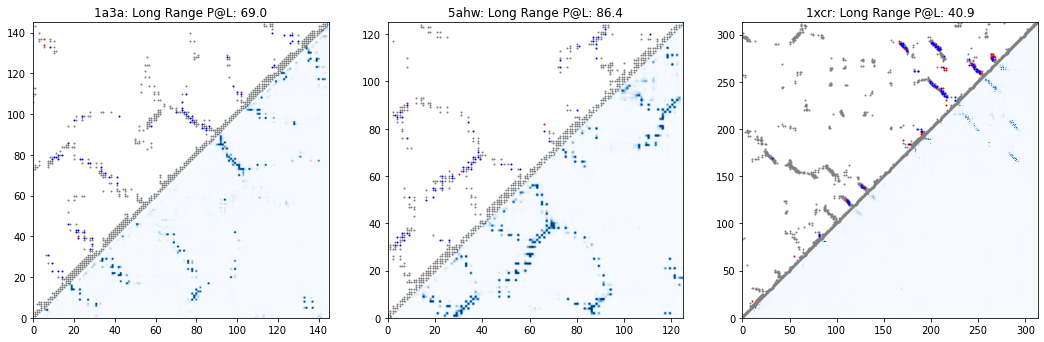

In [ ]:
fig, axes = plt.subplots(figsize=(18, 6), ncols=3)
for ax, name in zip(axes, PDB_IDS):
    prediction = esm2_predictions[name]
    target = contacts[name]
    plot_contacts_and_predictions(
        prediction, target, ax=ax, title = lambda prec: f"{name}: Long Range P@L: {100 * prec:0.1f}"
    )
plt.show()

### MSA Transformer Predictions

In [ ]:
msa_transformer, msa_transformer_alphabet = esm.pretrained.esm_msa1b_t12_100M_UR50S()
msa_transformer = msa_transformer.eval().cuda()
msa_transformer_batch_converter = msa_transformer_alphabet.get_batch_converter()

In [ ]:
msa_transformer_predictions = {}
msa_transformer_results = []
for name, inputs in msas.items():
    inputs = greedy_select(inputs, num_seqs=128) # can change this to pass more/fewer sequences
    msa_transformer_batch_labels, msa_transformer_batch_strs, msa_transformer_batch_tokens = msa_transformer_batch_converter([inputs])
    msa_transformer_batch_tokens = msa_transformer_batch_tokens.to(next(msa_transformer.parameters()).device)
    msa_transformer_predictions[name] = msa_transformer.predict_contacts(msa_transformer_batch_tokens)[0].cpu()
    metrics = {"id": name, "model": "MSA Transformer (Unsupervised)"}
    metrics.update(evaluate_prediction(msa_transformer_predictions[name], contacts[name]))
    msa_transformer_results.append(metrics)
msa_transformer_results = pd.DataFrame(msa_transformer_results)
display(msa_transformer_results)

,id,model,local_AUC,local_P@L,local_P@L2,local_P@L5,short_AUC,short_P@L,short_P@L2,short_P@L5,medium_AUC,medium_P@L,medium_P@L2,medium_P@L5,long_AUC,long_P@L,long_P@L2,long_P@L5
0,1a3a,MSA Transformer (Unsupervised),0.853126,0.765517,0.875000,0.827586,0.575057,0.317241,0.569444,0.862069,0.601065,0.337931,0.597222,0.827586,0.837919,0.724138,0.861111,0.896552
1,5ahw,MSA Transformer (Unsupervised),0.850377,0.736000,0.854839,0.920000,0.547282,0.288000,0.548387,0.880000,0.581426,0.320000,0.548387,0.880000,0.967116,0.896000,0.967742,1.000000
2,1xcr,MSA Transformer (Unsupervised),0.675652,0.469649,0.679487,0.870968,0.470373,0.249201,0.442308,0.709677,0.508027,0.316294,0.487179,0.677419,0.878467,0.769968,0.891026,0.967742


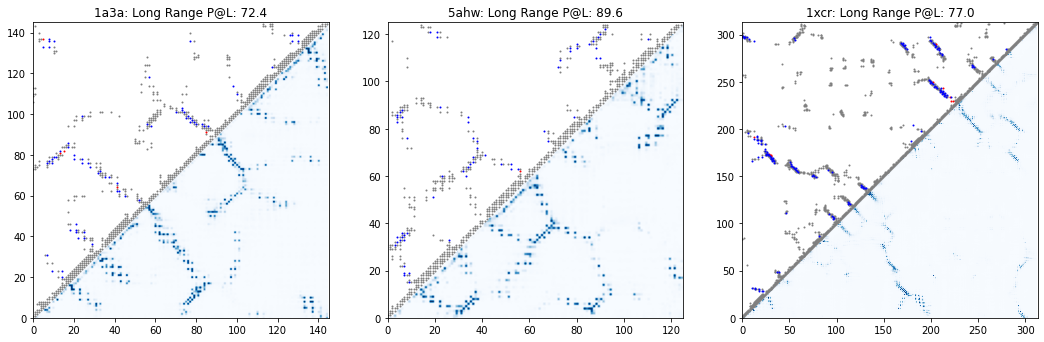

In [ ]:
fig, axes = plt.subplots(figsize=(18, 6), ncols=3)
for ax, name in zip(axes, PDB_IDS):
    prediction = msa_transformer_predictions[name]
    target = contacts[name]
    plot_contacts_and_predictions(
        prediction, target, ax=ax, title = lambda prec: f"{name}: Long Range P@L: {100 * prec:0.1f}"
    )
plt.show()